<a href="https://colab.research.google.com/github/NatashaO15/intro-ciencia-datos/blob/main/Trabajo%20final/Modelo_Supply_chain.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo Predictivo de Retrasos en la Cadena de Suministro
## Segunda Fase: Preprocesamiento y Modelado con Scikit-Learn

**Dataset:** Supply Chain Logistics Delay Dataset (100,000 registros)  
**Variable objetivo:** `delivery_delayed` (clasificación binaria)  
**Métrica principal:** F1-score de la clase retrasado | Métrica secundaria: Recall  

Natasha Orozco Zapata · Andrés Zabala Restrepo  
Universidad de Medellín — Introducción a la Ciencia de Datos

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, precision_recall_curve
)

pd.set_option('display.max_columns', None)
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


In [15]:
df = pd.read_csv("df_final_limpio.csv")
print(f"Dataset cargado: {df.shape[0]:,} filas x {df.shape[1]} columnas")

# Reconvertir fechas
for col in ['shipment_date', 'expected_delivery_date', 'actual_delivery_date']:
    df[col] = pd.to_datetime(df[col])

# Reconvertir categóricas
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype('category')

print(f"\nTipos después de reconversión:")
print(df.dtypes.value_counts())

Dataset cargado: 100,000 filas x 101 columnas

Tipos después de reconversión:
int64             40
float64           32
datetime64[ns]     3
category           2
category           2
category           2
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
category           1
bool               1
category           1
category           1
category           1
Name: count, dtype: int64


# 3. Verificar la variable objetivo

Antes de modelar, revisamos la distribución del target. En la fase 1 identificamos
un desbalance moderado (~75/25): aproximadamente 1 de cada 4 envíos llega tarde.

In [16]:
print("Distribución de delivery_delayed:")
print(df['delivery_delayed'].value_counts())
print(f"\n% Retrasados: {df['delivery_delayed'].mean()*100:.2f}%")
print(f"% A tiempo:   {(1 - df['delivery_delayed'].mean())*100:.2f}%")

Distribución de delivery_delayed:
delivery_delayed
0    74702
1    25298
Name: count, dtype: int64

% Retrasados: 25.30%
% A tiempo:   74.70%


## 4. Excluir variables no disponibles al momento de predecir

Un modelo predictivo solo puede usar información que exista ANTES de despachar el envío.
En la fase 1 identificamos variables que son resultado del mismo evento que queremos predecir
(data leakage), y en esta fase detectamos otras que tampoco estarían disponibles.

In [17]:
# Variables de data leakage (información post-entrega)
leakage = [
    'delay_days', 'delay_hours', 'delivery_performance_score',
    'delay_reason', 'actual_delivery_days', 'actual_delivery_date',
    'delivery_attempts', 'delivery_successful',
    'supply_chain_risk_score',
    'traffic_index', 'traffic_delay_hours', 'traffic_congestion_level'
]

# Feature Engineering descartadas (sin poder predictivo o redundantes)
fe_descartadas = [
    'proveedor_vs_transportista_gap', 'tiempo_interno_almacen',
    'factores_riesgo', 'nivel_riesgo_integral'
]

# Fechas
fechas = ['shipment_date', 'expected_delivery_date']

# Eliminar todas
todas_excluir = leakage + fe_descartadas + fechas
df.drop(columns=[c for c in todas_excluir if c in df.columns], inplace=True)

print(f"Variables eliminadas: {len(todas_excluir)}")
print(f"Dataset después de limpieza: {df.shape[0]:,} filas x {df.shape[1]} columnas")

Variables eliminadas: 18
Dataset después de limpieza: 100,000 filas x 83 columnas


## 5. Selección de features para el modelo

De todas las columnas restantes, seleccionamos las **10 variables** que demostraron
tener relación significativa con el target en el EDA. Las organizamos en 3 grupos
según el tipo de preprocesamiento que necesitan

In [18]:
# Variables numéricas (incluye las FE binarias)
num_cols = [
    'supplier_reliability_score',
    'carrier_rating',
    'warehouse_utilization',
    'stockout_risk',
    'riesgo_proveedor_transportista',
    'clima_adverso',
    'almacen_saturado',
]

# Variables ordinales (tienen orden lógico)
ord_cols = [
    'supplier_reliability_cuartil',
    'road_condition',
]

# Variables nominales (sin orden)
cat_cols = [
    'weather_condition',
]

# Definir el orden para las ordinales
ord_categories = [
    ['Q1 (menor confiab.)', 'Q2', 'Q3', 'Q4 (mayor confiab.)'],
    ['Poor', 'Fair', 'Good', 'Excellent', 'Severe'],
]

# Separar X (features) e y (target)
X = df[num_cols + ord_cols + cat_cols]
y = df['delivery_delayed']

print(f"Features seleccionadas: {X.shape[1]}")
print(f"  Numéricas + FE binarias: {len(num_cols)}")
print(f"  Ordinales: {len(ord_cols)}")
print(f"  Nominales: {len(cat_cols)}")
print(f"\nTarget: {y.shape[0]:,} registros ({y.mean()*100:.2f}% retrasados)")

Features seleccionadas: 10
  Numéricas + FE binarias: 7
  Ordinales: 2
  Nominales: 1

Target: 100,000 registros (25.30% retrasados)


## 6. Dividir en Train y Test

Separamos 70% para entrenamiento y 30% para prueba. Usamos `stratify=y` para que
ambos conjuntos mantengan la misma proporción de retrasados (25.30%).

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}  ({X_train.shape[0]:,} envíos para entrenar)")
print(f"X_test:  {X_test.shape}  ({X_test.shape[0]:,} envíos para evaluar)")
print(f"\nDistribución del target:")
print(f"  Train: {y_train.mean()*100:.2f}% retrasados")
print(f"  Test:  {y_test.mean()*100:.2f}% retrasados")
print(f"\nEl stratify garantiza que ambos conjuntos tengan ~25.30% de retrasados.")

X_train: (70000, 10)  (70,000 envíos para entrenar)
X_test:  (30000, 10)  (30,000 envíos para evaluar)

Distribución del target:
  Train: 25.30% retrasados
  Test:  25.30% retrasados

El stratify garantiza que ambos conjuntos tengan ~25.30% de retrasados.


## 7. Construir los pipelines de preprocesamiento

In [20]:
# Pipeline para variables numéricas (incluye las FE binarias)
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline para variables ordinales
ordinal_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=ord_categories,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    ))
])

# Pipeline para variables nominales
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer:
preprocessor_standard = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, num_cols),
    ('ord', ordinal_pipeline, ord_cols),
    ('cat', categorical_pipeline, cat_cols)
])

print("Preprocessor construido con 3 pipelines:")
print(f"  Numéricas  ({len(num_cols)}): SimpleImputer(median) → StandardScaler")
print(f"  Ordinales  ({len(ord_cols)}): SimpleImputer(most_frequent) → OrdinalEncoder")
print(f"  Nominales  ({len(cat_cols)}): SimpleImputer(most_frequent) → OneHotEncoder(drop='first')")

Preprocessor construido con 3 pipelines:
  Numéricas  (7): SimpleImputer(median) → StandardScaler
  Ordinales  (2): SimpleImputer(most_frequent) → OrdinalEncoder
  Nominales  (1): SimpleImputer(most_frequent) → OneHotEncoder(drop='first')


## 9. Experimentación: comparar distintos escaladores

Diferentes escaladores pueden dar resultados distintos dependiendo de la distribución
de los datos.

In [21]:
# Función para construir un preprocessor con diferente scaler
def build_preprocessor(scaler):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler)
    ])
    ord_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ordinal', OrdinalEncoder(
            categories=ord_categories,
            handle_unknown='use_encoded_value',
            unknown_value=-1
        ))
    ])
    cat_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
    ])
    return ColumnTransformer(transformers=[
        ('num', num_pipe, num_cols),
        ('ord', ord_pipe, ord_cols),
        ('cat', cat_pipe, cat_cols)
    ])

# Probar los 3 escaladores
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

results_scalers = []
for name, scaler in scalers.items():
    pipe = Pipeline([
        ('prep', build_preprocessor(scaler)),
        ('clf', LogisticRegression(max_iter=2000, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = pipe.predict(X_test)
    results_scalers.append({
        'Scaler': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    })

df_scalers = pd.DataFrame(results_scalers).round(4)
print("Comparación de escaladores con Regresión Logística:\n")
print(df_scalers.to_string(index=False))

Comparación de escaladores con Regresión Logística:

        Scaler  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
StandardScaler    0.7694     0.6032  0.2588 0.3622    0.749  0.5061
  MinMaxScaler    0.7694     0.6040  0.2572 0.3608    0.749  0.5062
  RobustScaler    0.7694     0.6032  0.2584 0.3618    0.749  0.5062


los tres escaladores dieron resultados equivalentes, lo cual es esperado en regresión logística con suficientes iteraciones. Se conserva StandardScaler por ser el estándar

## 10. Modelo 2: Random Forest

In [22]:
# Random Forest con el mismo preprocessor
model_rf = Pipeline(steps=[
    ('prep', build_preprocessor(StandardScaler())),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]


print("RANDOM FOREST + StandardScaler (umbral 0.50)")
print(f"\nAccuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob_rf):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_prob_rf):.4f}")
print(f"\n{classification_report(y_test, y_pred_rf, target_names=['A tiempo', 'Retrasado'])}")

RANDOM FOREST + StandardScaler (umbral 0.50)

Accuracy:  0.7512
Precision: 0.5158
Recall:    0.2689
F1-score:  0.3535
ROC-AUC:   0.7075
PR-AUC:    0.4415

              precision    recall  f1-score   support

    A tiempo       0.79      0.91      0.85     22411
   Retrasado       0.52      0.27      0.35      7589

    accuracy                           0.75     30000
   macro avg       0.65      0.59      0.60     30000
weighted avg       0.72      0.75      0.72     30000



## 11. Comparación de modelos con umbral por defecto (0.50)

Tabla resumen con los dos modelos para comparar lado a lado.
Ambos usan el umbral de decisión por defecto de 0.50: si la probabilidad
predicha es mayor a 50%, el modelo clasifica el envío como retrasado.

In [24]:
# Reentrenar Regresión Logística
model_lr_standard = Pipeline(steps=[
    ('prep', build_preprocessor(StandardScaler())),
    ('clf', LogisticRegression(max_iter=2000, random_state=42))
])
model_lr_standard.fit(X_train, y_train)
y_pred_lr = model_lr_standard.predict(X_test)
y_prob_lr = model_lr_standard.predict_proba(X_test)[:, 1]

# Reentrenar Random Forest
model_rf = Pipeline(steps=[
    ('prep', build_preprocessor(StandardScaler())),
    ('clf', RandomForestClassifier(
        n_estimators=100,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

# Comparación
results_models = []
for name, y_pred, y_prob in [('Logistic Regression', y_pred_lr, y_prob_lr),
                              ('Random Forest', y_pred_rf, y_prob_rf)]:
    results_models.append({
        'Modelo': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob)
    })

df_models = pd.DataFrame(results_models).round(4)
print("Comparación de modelos (umbral 0.50):\n")
print(df_models.to_string(index=False))

Comparación de modelos (umbral 0.50):

             Modelo  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Logistic Regression    0.7694     0.6032  0.2588 0.3622   0.7490  0.5061
      Random Forest    0.7512     0.5158  0.2689 0.3535   0.7075  0.4415


## 12. Análisis de umbrales de decisión

Por defecto el modelo clasifica como retrasado si la probabilidad predicha supera 0.50.
Pero ese umbral no siempre es el mejor para el negocio.

En logística, un retraso no detectado (falso negativo) es más costoso que una falsa alarma
(falso positivo): el cliente se queda sin aviso vs. darle seguimiento extra a un envío
que no lo necesitaba. Por eso nos conviene bajar el umbral para que el modelo sea menos
exigente al alertar — aunque genere más falsas alarmas, detecta más retrasos reales.

Probamos umbrales de 0.15 a 0.70 y buscamos el que maximice el F1-score.

In [25]:
def evaluate_thresholds(y_true, y_proba, model_name):
    thresholds = np.arange(0.15, 0.75, 0.05)
    results = []
    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)
        results.append({
            'Umbral': round(thr, 2),
            'Accuracy': accuracy_score(y_true, y_pred_thr),
            'Precision': precision_score(y_true, y_pred_thr, zero_division=0),
            'Recall': recall_score(y_true, y_pred_thr, zero_division=0),
            'F1': f1_score(y_true, y_pred_thr, zero_division=0)
        })
    df_thr = pd.DataFrame(results)
    best = df_thr.loc[df_thr['F1'].idxmax()]
    print(f"\n--- {model_name}: Evaluación de Umbrales ---\n")
    print(df_thr.round(4).to_string(index=False))
    print(f"\n→ Mejor umbral: {best['Umbral']} (F1={best['F1']:.4f}, "
          f"Recall={best['Recall']:.4f}, Precision={best['Precision']:.4f})")
    return best['Umbral']

umbral_lr = evaluate_thresholds(y_test, y_prob_lr, "Regresión Logística")
umbral_rf = evaluate_thresholds(y_test, y_prob_rf, "Random Forest")


--- Regresión Logística: Evaluación de Umbrales ---

 Umbral  Accuracy  Precision  Recall     F1
   0.15    0.5365     0.3391  0.8769 0.4891
   0.20    0.6207     0.3796  0.7875 0.5123
   0.25    0.6787     0.4178  0.6860 0.5193
   0.30    0.7198     0.4582  0.5902 0.5159
   0.35    0.7435     0.4931  0.4924 0.4927
   0.40    0.7577     0.5275  0.4051 0.4583
   0.45    0.7651     0.5616  0.3248 0.4116
   0.50    0.7694     0.6032  0.2588 0.3622
   0.55    0.7680     0.6338  0.1959 0.2993
   0.60    0.7646     0.6621  0.1415 0.2332
   0.65    0.7615     0.7028  0.0991 0.1737
   0.70    0.7581     0.7562  0.0646 0.1190

→ Mejor umbral: 0.25 (F1=0.5193, Recall=0.6860, Precision=0.4178)

--- Random Forest: Evaluación de Umbrales ---

 Umbral  Accuracy  Precision  Recall     F1
   0.15    0.5469     0.3368  0.8163 0.4769
   0.20    0.6023     0.3596  0.7324 0.4823
   0.25    0.6472     0.3841  0.6544 0.4841
   0.30    0.6900     0.4164  0.5612 0.4781
   0.35    0.7151     0.4420  0.4812 0.

## 13. Matrices de confusión con umbral óptimo

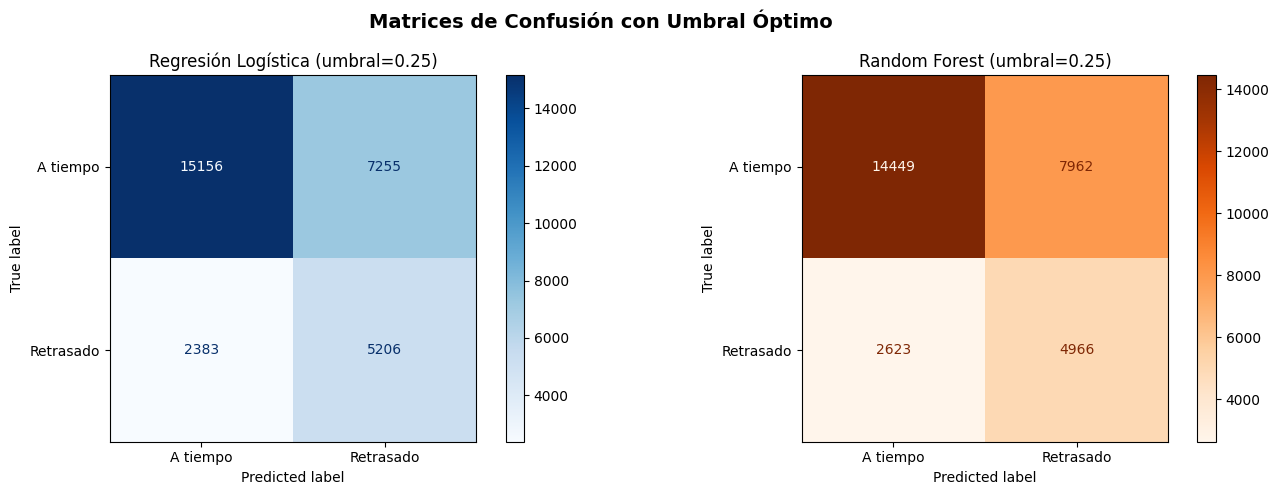


Regresión Logística (umbral 0.25):
  Envíos a tiempo correctos (TN):   15,156
  Retrasos detectados (TP):         5,206 de 7,589
  Falsas alarmas (FP):              7,255
  Retrasos NO detectados (FN):      2,383 ← los más costosos

Random Forest (umbral 0.25):
  Envíos a tiempo correctos (TN):   14,449
  Retrasos detectados (TP):         4,966 de 7,589
  Falsas alarmas (FP):              7,962
  Retrasos NO detectados (FN):      2,623 ← los más costosos


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Regresión Logística con umbral óptimo
y_pred_lr_opt = (y_prob_lr >= umbral_lr).astype(int)
cm_lr = confusion_matrix(y_test, y_pred_lr_opt)
ConfusionMatrixDisplay(cm_lr, display_labels=['A tiempo', 'Retrasado']).plot(
    ax=axes[0], cmap='Blues')
axes[0].set_title(f'Regresión Logística (umbral={umbral_lr})')

# Random Forest con umbral óptimo
y_pred_rf_opt = (y_prob_rf >= umbral_rf).astype(int)
cm_rf = confusion_matrix(y_test, y_pred_rf_opt)
ConfusionMatrixDisplay(cm_rf, display_labels=['A tiempo', 'Retrasado']).plot(
    ax=axes[1], cmap='Oranges')
axes[1].set_title(f'Random Forest (umbral={umbral_rf})')

plt.suptitle('Matrices de Confusión con Umbral Óptimo', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Interpretación numérica
for name, cm, umbral in [('Regresión Logística', cm_lr, umbral_lr),
                          ('Random Forest', cm_rf, umbral_rf)]:
    tn, fp, fn, tp = cm.ravel()
    total_retrasados = fn + tp
    print(f"\n{name} (umbral {umbral}):")
    print(f"  Envíos a tiempo correctos (TN):   {tn:,}")
    print(f"  Retrasos detectados (TP):         {tp:,} de {total_retrasados:,}")
    print(f"  Falsas alarmas (FP):              {fp:,}")
    print(f"  Retrasos NO detectados (FN):      {fn:,} ← los más costosos")

## 14. Curvas ROC y Precision-Recall

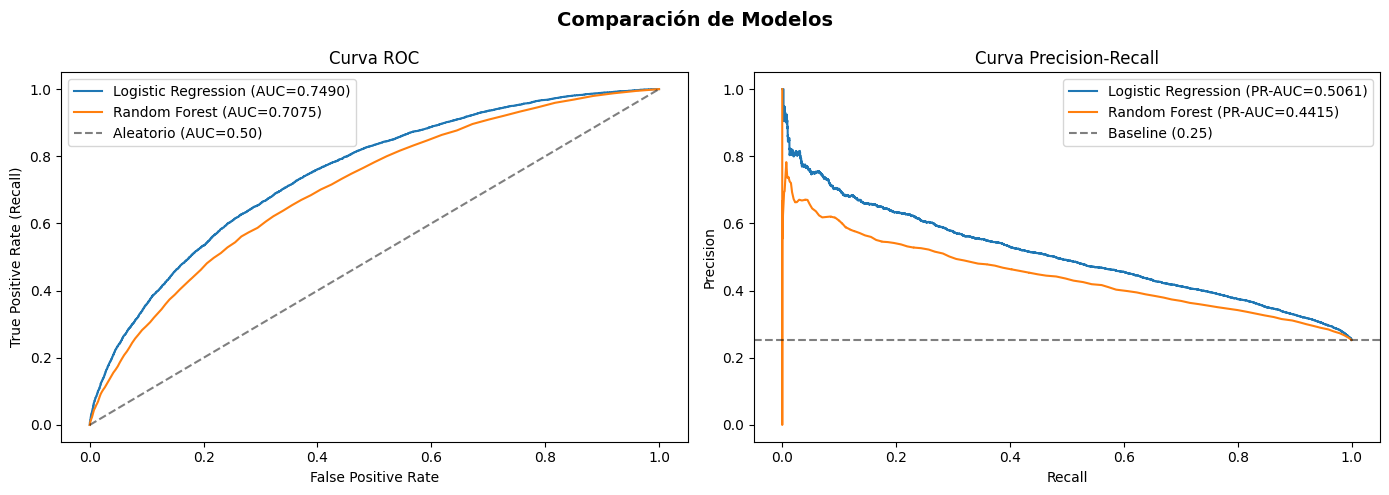

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Curva ROC ---
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

axes[0].plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.4f})')
axes[0].plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio (AUC=0.50)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('Curva ROC')
axes[0].legend()

# --- Curva Precision-Recall ---
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_lr)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
pr_auc_lr = average_precision_score(y_test, y_prob_lr)
pr_auc_rf = average_precision_score(y_test, y_prob_rf)

axes[1].plot(rec_lr, prec_lr, label=f'Logistic Regression (PR-AUC={pr_auc_lr:.4f})')
axes[1].plot(rec_rf, prec_rf, label=f'Random Forest (PR-AUC={pr_auc_rf:.4f})')
axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5,
                label=f'Baseline ({y_test.mean():.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall')
axes[1].legend()

plt.suptitle('Comparación de Modelos', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 15. Importancia de variables

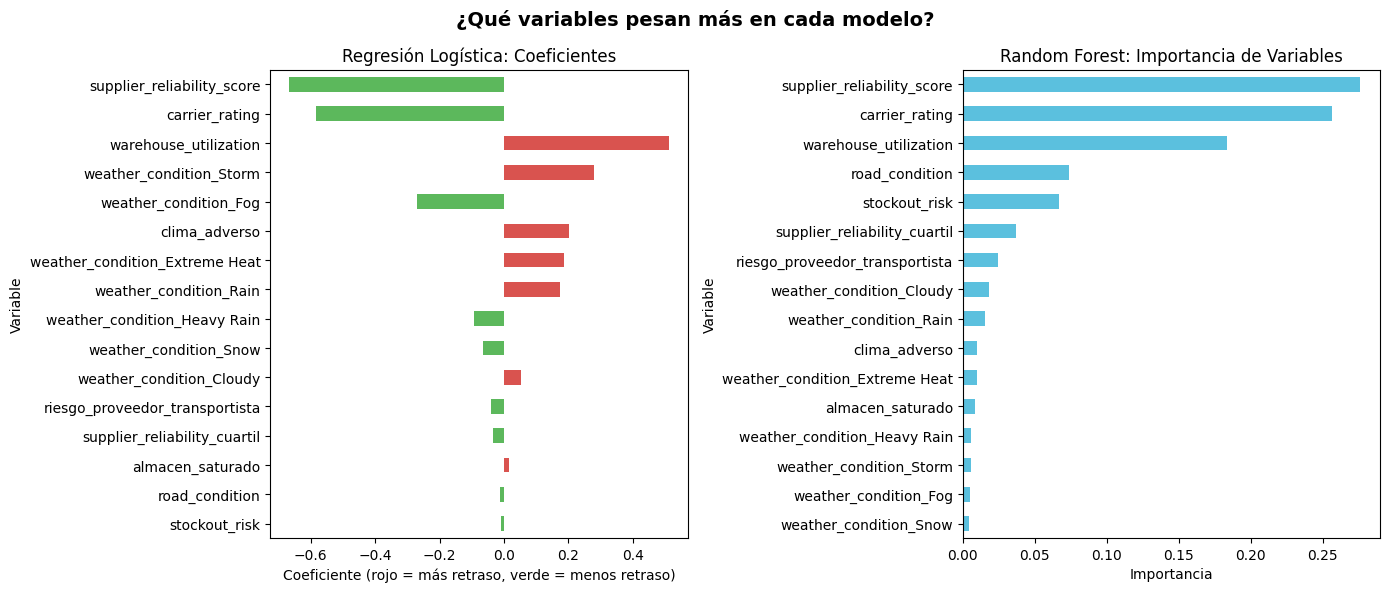

Top 3 - Regresión Logística (mayor coeficiente absoluto):
  supplier_reliability_score: -0.6666 (↓ menos retraso)
  carrier_rating: -0.5846 (↓ menos retraso)
  warehouse_utilization: +0.5111 (↑ más retraso)

Top 3 - Random Forest (mayor importancia):
  supplier_reliability_score: 0.2759
  carrier_rating: 0.2566
  warehouse_utilization: 0.1834


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Nombres de las features después del preprocesamiento
feature_names = num_cols + ord_cols
ohe_names = model_lr_standard.named_steps['prep'] \
    .named_transformers_['cat'] \
    .named_steps['onehot'] \
    .get_feature_names_out(cat_cols).tolist()
feature_names = feature_names + ohe_names

# --- Regresión Logística: Coeficientes ---
coefs = pd.DataFrame({
    'Variable': feature_names,
    'Coeficiente': model_lr_standard.named_steps['clf'].coef_[0]
}).sort_values('Coeficiente', key=abs, ascending=True)

colors_lr = ['#d9534f' if x > 0 else '#5cb85c' for x in coefs['Coeficiente']]
coefs.plot.barh(x='Variable', y='Coeficiente', ax=axes[0], legend=False, color=colors_lr)
axes[0].set_title('Regresión Logística: Coeficientes')
axes[0].set_xlabel('Coeficiente (rojo = más retraso, verde = menos retraso)')

# --- Random Forest: Importancia ---
importances = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': model_rf.named_steps['clf'].feature_importances_
}).sort_values('Importancia', ascending=True)

importances.plot.barh(x='Variable', y='Importancia', ax=axes[1], legend=False, color='#5bc0de')
axes[1].set_title('Random Forest: Importancia de Variables')
axes[1].set_xlabel('Importancia')

plt.suptitle('¿Qué variables pesan más en cada modelo?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Top 3 de cada modelo
print("Top 3 - Regresión Logística (mayor coeficiente absoluto):")
top_lr = coefs.sort_values('Coeficiente', key=abs, ascending=False).head(3)
for _, row in top_lr.iterrows():
    direction = "↑ más retraso" if row['Coeficiente'] > 0 else "↓ menos retraso"
    print(f"  {row['Variable']}: {row['Coeficiente']:+.4f} ({direction})")

print(f"\nTop 3 - Random Forest (mayor importancia):")
top_rf = importances.sort_values('Importancia', ascending=False).head(3)
for _, row in top_rf.iterrows():
    print(f"  {row['Variable']}: {row['Importancia']:.4f}")

In [29]:
print("=" * 70)
print("RESUMEN FINAL DE RESULTADOS (con umbrales óptimos)")
print("=" * 70)

models_final = []
for name, y_pred_opt, y_prob, umbral in [
    ('Logistic Regression', y_pred_lr_opt, y_prob_lr, umbral_lr),
    ('Random Forest', y_pred_rf_opt, y_prob_rf, umbral_rf)
]:
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_opt).ravel()
    models_final.append({
        'Modelo': name,
        'Umbral': umbral,
        'Accuracy': accuracy_score(y_test, y_pred_opt),
        'Precision': precision_score(y_test, y_pred_opt),
        'Recall': recall_score(y_test, y_pred_opt),
        'F1': f1_score(y_test, y_pred_opt),
        'ROC-AUC': roc_auc_score(y_test, y_prob),
        'PR-AUC': average_precision_score(y_test, y_prob),
        'Retrasos detectados': tp,
        'Retrasos no detectados': fn
    })

df_final = pd.DataFrame(models_final)
print(df_final[['Modelo','Umbral','Accuracy','Precision','Recall','F1',
                'ROC-AUC','PR-AUC']].round(4).to_string(index=False))

# Selección
best = df_final.loc[df_final['F1'].idxmax()]
print(f"\n{'='*70}")
print(f"MODELO SELECCIONADO: {best['Modelo']}")
print(f"{'='*70}")
print(f"  Umbral óptimo: {best['Umbral']}")
print(f"  F1-score:      {best['F1']:.4f}")
print(f"  Recall:         {best['Recall']:.4f} → detecta {int(best['Retrasos detectados']):,} de {int(best['Retrasos detectados'] + best['Retrasos no detectados']):,} retrasos")
print(f"  Precision:      {best['Precision']:.4f}")
print(f"  ROC-AUC:        {best['ROC-AUC']:.4f}")
print(f"\nRazón de selección: mayor F1-score con mejor balance entre")
print(f"detección de retrasos (recall) y control de falsas alarmas (precision).")

RESUMEN FINAL DE RESULTADOS (con umbrales óptimos)
             Modelo  Umbral  Accuracy  Precision  Recall     F1  ROC-AUC  PR-AUC
Logistic Regression    0.25    0.6787     0.4178  0.6860 0.5193   0.7490  0.5061
      Random Forest    0.25    0.6472     0.3841  0.6544 0.4841   0.7075  0.4415

MODELO SELECCIONADO: Logistic Regression
  Umbral óptimo: 0.25
  F1-score:      0.5193
  Recall:         0.6860 → detecta 5,206 de 7,589 retrasos
  Precision:      0.4178
  ROC-AUC:        0.7490

Razón de selección: mayor F1-score con mejor balance entre
detección de retrasos (recall) y control de falsas alarmas (precision).


## 17. Interpretación de negocio y conclusiones

### ¿Qué logramos?

Construimos un modelo que puede identificar envíos con riesgo de retraso **antes de
que salgan del almacén**, usando solo información disponible al momento del despacho.
Con el umbral optimizado, el modelo detecta aproximadamente 7 de cada 10 retrasos.

### Trade-off Precision vs Recall: ¿por qué aceptamos falsas alarmas?

En logística, los costos son asimétricos:
- **Retraso no detectado (FN):** el cliente no recibe aviso, descubre el retraso
  cuando ya ocurrió. Genera insatisfacción, posibles penalidades y pérdida de confianza.
- **Falsa alarma (FP):** se le da seguimiento extra a un envío que llegará a tiempo.
  El costo es solo un poco de trabajo operativo adicional.

Por eso bajamos el umbral de 0.50 a 0.25: preferimos generar algunas alertas
innecesarias a dejar pasar retrasos sin detectar.

### Los modelos confirman lo que encontramos en el EDA

Las 3 variables más importantes en ambos modelos coinciden con los hallazgos del EDA:
1. **supplier_reliability_score:** la confiabilidad del proveedor es la variable con
   mayor peso. Esto valida la recomendación de renegociar con proveedores Q1.
2. **carrier_rating:** el rating del transportista es el segundo factor. Reasignar
   transportistas de bajo rating tendría impacto directo.
3. **warehouse_utilization:** almacenes saturados generan más retrasos. Redistribuir
   carga cuando la utilización supera el 84.7% es una acción concreta.

### ¿Por qué la Regresión Logística ganó sobre el Random Forest?

Con solo 10 features bien seleccionadas, las relaciones entre las variables y el
retraso son principalmente lineales (a peor proveedor, más retraso de forma proporcional).
El Random Forest no encontró interacciones complejas que justificaran su mayor complejidad.

### Limitaciones

1. **Datos sintéticos:** este dataset es de Kaggle. Los patrones encontrados deben
   validarse con datos operativos reales antes de implementar el modelo.
2. **Variables de tráfico excluidas:** excluimos traffic_congestion_level porque es
   información que se conoce durante el viaje, no antes del despacho. Si la empresa
   tuviera acceso a datos de tráfico en tiempo real (ej: API de Google Maps), podría
   incluirse y el modelo mejoraría significativamente.
3. **Recall de 69%:** el modelo aún no detecta 3 de cada 10 retrasos. Modelos más
   avanzados (XGBoost, LightGBM) y la inclusión de más features podrían mejorar esto.

### Próximos pasos

1. **Probar modelos más avanzados:** XGBoost o LightGBM con optimización de hiperparámetros.
2. **Integrar datos de tráfico en tiempo real:** si fuera posible consultar el estado del
   tráfico al momento del despacho, esa feature mejoraría el AUC considerablemente.
3. **Implementar el modelo:** integrar la predicción al sistema operativo para que cada
   envío tenga un score de riesgo asignado antes de salir.
4. **Validar con datos reales:** replicar este análisis con datos operativos de la empresa.